# LINEAR REGRESSION MODEL FOR EXPECTED CARRIER TRANSIT

## Part I — Project Overview and Analytical Framing

### 1.1. Project Overview

This notebook builds a Linear Regression benchmark model to estimate the **expected carrier transit days** for each delivered order.

The purpose of the model is not to prove causal relationships between predictors and delivery time. Instead, the model is used to create a fair benchmark:

> Given an order’s distance, package weight, package volume, order timing, and seller state, how many carrier transit days should this order normally take?

After estimating the expected transit days for each order, the model calculates an order-level residual:

$$
\text{Model-adjusted residual}_i
=
\text{Actual transit days}_i
-
\text{Expected transit days}_i
$$

Where:

- **Actual transit days** = the real number of days the carrier took to deliver the order.
- **Expected transit days** = the model-predicted transit days for that order.
- **Residual > 0** means the order took longer than expected.
- **Residual < 0** means the order was delivered faster than expected.

The selected model is an **OLS model fitted on `log1p(carrier_transit_time_day)`**. Predictions are converted back to day scale using:

$$
\text{Expected transit days}_i
=
\exp(\widehat{\log(1 + \text{transit days}_i)}) - 1
$$

No smearing correction is used because the final dashboard focuses on **median residual benchmarking**, not mean-level prediction.

---

### 1.2. Business Question

The main business question is:

> Which states show unusually poor carrier delivery performance after adjusting for order characteristics?

Looking only at raw delivery time can be misleading. A state may have longer delivery time simply because its orders are farther away, heavier, larger, or shipped from different seller locations.

Therefore, this model adjusts for objective order-level factors before comparing delivery performance across states.

Instead of asking:

> Which states have the longest actual delivery time?

This analysis asks:

> Which states are slower than expected after adjusting for distance, package characteristics, order timing, and seller state?

---

### 1.3. State-Level Dashboard Metrics

The dashboard aggregates order-level model results to the state level.

For each state:

$$
\text{Median Residual Days}
=
\text{Median}(\text{Actual transit days}_i - \text{Expected transit days}_i)
$$

This means the state-level residual is calculated as the **median of order-level residuals**, not as the difference between state-level averages.

Interpretation:

- **Median Residual > 0**: a typical order in that state is slower than expected.
- **Median Residual < 0**: a typical order in that state is faster than expected.
- **Median Residual ≈ 0**: delivery performance is close to model expectation.

The dashboard also uses:

$$
\text{Delay Burden}
=
\text{Late Orders}
\times
\text{Positive Median Residual Days}
$$

Where:

- **Late Orders** = orders delivered after the estimated delivery date.
- **Positive Median Residual Days** = the delay part of the median residual.
- If median residual is negative or zero, it is treated as 0 for delay burden.

This avoids giving negative burden to states that are faster than expected.

---

### 1.4. Why Homogeneous Orders Are Used

This analysis focuses only on **homogeneous orders**, meaning orders that involve one seller and one product type.

The reason is related to the grain of the OLIST order dataset. The main delivery outcome variables, such as `order_delivered_customer_date`, `order_estimated_delivery_date`, `carrier_transit_time_day`, and `total_delivery_lead_time_day`, are recorded at the **order level**, not at the item, product, or seller-shipment level.

For complex orders with multiple products or multiple sellers, the dataset only provides one final delivery outcome for the whole order. It does not show which seller, product, or shipment component actually caused the delay.

By restricting the model to homogeneous orders, each delivery outcome is more directly linked to one seller, one product type, and one carrier transit process. This reduces aggregation bias and makes the model-adjusted residual easier to interpret.

## PART II — DATA SETUP AND BASE FEATURE ENGINEERING

### 2.1. Import

In [4]:
!pip install pandas openpyxl

In [5]:
# Import all libraries required for data preparation, EDA, OLS modeling, evaluation, and export

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [6]:
file_path = r"C:\Users\PC\Downloads\SAT FILE\DATA ANALYST TOOLS\OLIST Project\Olist- Brazil E-Commerce\Cleaned Data by Python (Ver 3)\master_dataset_final_ver3.csv"

df = pd.read_csv(file_path, sep=',', encoding='utf-8')
pd.set_option('display.max_columns', None)

df.head()

,order_id,customer_id,customer_unique_id,customer_city,customer_state,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,order_approval_time_hour,seller_handling_time_day,carrier_transit_time_day,total_delivery_lead_time_day,promise_gap_day,item_count,product_count,seller_count,multi_seller_flag,multi_product_flag,order_structure_type,total_price,total_freight,total_weight_g,total_volume_cm3,freight_to_price_ratio,review_score,product_id,product_category_name_english,seller_id,seller_city,seller_state,customer_zip_code_prefix,seller_zip_code_prefix,cust_lat,cust_lng,seller_lat,seller_lng,seller_city.1,seller_state.1
0,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,830d5b7aaa3b6f1e9ad63703bec97d23,sao joaquim da barra,SP,delivered,2016-09-15 12:16:00,2016-11-09 07:47:00,2016-10-04,0.000000,53.204861,1.608333,54.813194,36.324306,3,1,1,False,False,Homogeneous,134.97,8.49,3000,12288,0.0629,1.0,5a6b04657a4c5ee34285d1e4619a96b4,health_beauty,ecccfa2bb93b34a3bf033cc5d1dcdc69,curitiba,PR,14600,81810.0,-20.585751,-47.863693,-25.507014,-49.275963,curitiba,PR
1,3b697a20d9e427646d92567910af6d57,355077684019f7f60a031656bd7262b8,32ea3bdedab835c3aa6cb68ce66565ef,sao paulo,SP,delivered,2016-10-03 09:44:00,2016-10-26 14:02:00,2016-10-27,78.100000,16.925000,3.000000,23.179167,-0.415278,1,1,1,False,False,Homogeneous,29.90,15.56,300,4096,0.5204,4.0,3ae08df6bcbfe23586dd431c40bddbb7,watches_gifts,522620dcb18a6b31cd7bdf73665113a9,cascavel,PR,4106,85801.0,-23.581451,-46.635029,-24.959184,-53.462644,cascavel,PR
2,be5bc2f0da14d8071e2d45451ad119d9,7ec40b22510fdbea1b08921dd39e63d8,2f64e403852e6893ae37485d5fcacdaf,panambi,RS,delivered,2016-10-03 16:56:00,2016-10-27 18:19:00,2016-11-07,71.116667,15.020833,6.073611,24.057639,-10.236806,1,1,1,False,False,Homogeneous,21.90,17.19,400,4096,0.7849,4.0,fd7fd78fd3cbc1b0a6370a7909c0a629,sports_leisure,f09b760d23495ac9a7e00d29b769007c,catanduva,SP,98280,15802.0,-28.293541,-53.502238,-21.143389,-48.995314,catanduva,SP
3,a41c8759fbe7aab36ea07e038b2d4465,6f989332712d3222b6571b1cf5b835ce,61db744d2f835035a5625b59350c6b63,porto alegre,RS,delivered,2016-10-03 21:13:00,2016-11-03 10:58:00,2016-11-29,29.966667,20.365278,8.959028,30.572917,-25.543056,1,1,1,False,False,Homogeneous,36.49,17.24,767,4160,0.4725,3.0,b72b39418216e944bb34e35f4d3ea8c7,sports_leisure,45d33f715e24d15a6ccf5c17b3a23e3c,sorocaba,SP,90040,18015.0,-30.041161,-51.213661,-23.502755,-47.430451,sorocaba,SP
4,d207cc272675637bfed0062edffd0818,b8cf418e97ae795672d326288dfab7a7,8d3a54507421dbd2ce0a1d58046826e0,hortolandia,SP,delivered,2016-10-03 22:06:00,2016-10-31 11:07:00,2016-11-23,12.366667,17.163194,9.863889,27.542361,-22.536806,1,1,1,False,False,Homogeneous,119.90,13.56,2050,14960,0.1131,1.0,107177bf61755f05c604fe57e02467d6,furniture_decor,cca3071e3e9bb7d12640c9fbe2301306,ibitinga,SP,13185,14940.0,-22.892792,-47.173849,-21.757321,-48.829744,ibitinga,SP


### 2.2. Feature Engineering and Model Variable Selection

In [8]:
df_homo = df[df['order_structure_type']== 'Homogeneous'].copy()

In [9]:
df_homo = df_homo.copy()

# Create time features
df_homo["order_purchase_timestamp"] = pd.to_datetime(
    df_homo["order_purchase_timestamp"],
    errors="coerce"
)
df_homo["order_month"] = df_homo["order_purchase_timestamp"].dt.month
df_homo["order_dayofweek"] = df_homo["order_purchase_timestamp"].dt.dayofweek

# Create distance feature using Haversine formula
def haversine_km(lat1, lon1, lat2, lon2):
    earth_radius_km = 6371.0088

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )
    c = 2 * np.arcsin(np.sqrt(a))
    return earth_radius_km * c

df_homo["distance_km"] = haversine_km(
    df_homo["seller_lat"],
    df_homo["seller_lng"],
    df_homo["cust_lat"],
    df_homo["cust_lng"]
)
df_homo[["distance_km", "order_month", "order_dayofweek"]].head()

,distance_km,order_month,order_dayofweek
0,565.960594,9,3
1,708.755226,10,0
2,915.913677,10,0
3,818.147634,10,0
4,212.015158,10,0


In [10]:
model_cols = [
    "carrier_transit_time_day",
    "distance_km",
    "total_weight_g",
    "total_volume_cm3",
    "order_month",
    "order_dayofweek",
    "seller_state"
]
df_model = df_homo[model_cols].copy()

df_model.head()

,carrier_transit_time_day,distance_km,total_weight_g,total_volume_cm3,order_month,order_dayofweek,seller_state
0,1.608333,565.960594,3000,12288,9,3,PR
1,3.000000,708.755226,300,4096,10,0,PR
2,6.073611,915.913677,400,4096,10,0,SP
3,8.959028,818.147634,767,4160,10,0,SP
4,9.863889,212.015158,2050,14960,10,0,SP


## Part III — DATA PREPROCESSING & EDA

### 3.1. Data Type Conversion

In [13]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91364 entries, 0 to 94443
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   carrier_transit_time_day  91364 non-null  float64
 1   distance_km               90908 non-null  float64
 2   total_weight_g            91364 non-null  int64  
 3   total_volume_cm3          91364 non-null  int64  
 4   order_month               91364 non-null  int32  
 5   order_dayofweek           91364 non-null  int32  
 6   seller_state              91364 non-null  object 
dtypes: float64(2), int32(2), int64(2), object(1)
memory usage: 4.9+ MB


### 3.2. Field Validity and Structural Checks

In [15]:
df_check = df_model.copy()

required_cols = [
    "carrier_transit_time_day",
    "distance_km",
    "total_weight_g",
    "total_volume_cm3",
    "order_month",
    "order_dayofweek",
    "seller_state"
]
missing_cols = [col for col in required_cols if col not in df_check.columns]

if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

checks = []

def add_check(check_name, condition, note):
    condition = pd.Series(condition, index=df_check.index).fillna(False).astype(bool)
    
    checks.append({
        "check_name": check_name,
        "invalid_count": int(condition.sum()),
        "invalid_pct": round(condition.mean() * 100, 4),
        "sample_index": condition[condition].index[:5].tolist(),
        "note": note
    })
    
# Structural checks
add_check(
    "Full-row duplicate check",
    df_check.duplicated(keep=False),
    "Duplicated rows based on all model columns. Inspect only, not always an error."
)
for col in required_cols:
    add_check(
        f"Missing value check - {col}",
        df_check[col].isna(),
        "Column should not have missing values before modeling."
    )
# Numeric checks
numeric_cols = [
    "carrier_transit_time_day",
    "distance_km",
    "total_weight_g",
    "total_volume_cm3",
    "order_month",
    "order_dayofweek"
]

for col in numeric_cols:
    add_check(
        f"Infinite value check - {col}",
        np.isinf(df_check[col]),
        "Numeric column should not contain inf or -inf."
    )
add_check(
    "carrier_transit_time_day non-negative check",
    df_check["carrier_transit_time_day"] < 0,
    "carrier_transit_time_day should be >= 0."
)
add_check(
    "distance_km non-negative check",
    df_check["distance_km"] < 0,
    "distance_km should be >= 0."
)
add_check(
    "total_weight_g positive check",
    df_check["total_weight_g"] <= 0,
    "total_weight_g should be > 0."
)
add_check(
    "total_volume_cm3 positive check",
    df_check["total_volume_cm3"] <= 0,
    "total_volume_cm3 should be > 0."
)
add_check(
    "order_month range check",
    ~df_check["order_month"].between(1, 12),
    "order_month should be between 1 and 12."
)
add_check(
    "order_dayofweek range check",
    ~df_check["order_dayofweek"].between(0, 6),
    "order_dayofweek should be between 0 and 6."
)

# Categorical checks
br_states = {
    "AC", "AL", "AP", "AM", "BA", "CE", "DF", "ES", "GO",
    "MA", "MT", "MS", "MG", "PA", "PB", "PR", "PE", "PI",
    "RJ", "RN", "RS", "RO", "RR", "SC", "SP", "SE", "TO"
}

add_check(
    "seller_state empty string check",
    df_check["seller_state"].astype(str).str.strip().eq(""),
    "seller_state should not be empty."
)
add_check(
    "seller_state Brazil code check",
    ~df_check["seller_state"].isin(br_states),
    "seller_state should be a valid Brazil state code."
)
check_summary_model = pd.DataFrame(checks).sort_values(
    by="invalid_count",
    ascending=False
)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

display(check_summary_model)

,check_name,invalid_count,invalid_pct,sample_index,note
16,total_weight_g positive check,1315,1.4393,"[8, 199, 424, 493, 641]",total_weight_g should be > 0.
17,total_volume_cm3 positive check,1309,1.4327,"[8, 199, 424, 493, 641]",total_volume_cm3 should be > 0.
2,Missing value check - distance_km,456,0.4991,"[2732, 2748, 2814, 2984, 3057]",Column should not have missing values before modeling.
0,Full-row duplicate check,6,0.0066,"[267, 268, 2141, 2142, 73305]","Duplicated rows based on all model columns. Inspect only, not always an error."
21,seller_state Brazil code check,3,0.0033,"[76279, 86590, 86882]",seller_state should be a valid Brazil state code.
5,Missing value check - order_month,0,0.0000,[],Column should not have missing values before modeling.
14,carrier_transit_time_day non-negative check,0,0.0000,[],carrier_transit_time_day should be >= 0.
20,seller_state empty string check,0,0.0000,[],seller_state should not be empty.
19,order_dayofweek range check,0,0.0000,[],order_dayofweek should be between 0 and 6.
18,order_month range check,0,0.0000,[],order_month should be between 1 and 12.


In [16]:
invalid_states = ~df_model["seller_state"].isin(br_states)

df_model[invalid_states]

,carrier_transit_time_day,distance_km,total_weight_g,total_volume_cm3,order_month,order_dayofweek,seller_state
76279,7.309722,1173.202823,800,14000,5,0,"rio grande do sul, brasil,RS"""
86590,8.174306,1884.972611,522,4160,7,1,"rio de janeiro, brasil,RJ"""
86882,3.951389,344.991153,267,2688,7,3,"rio de janeiro, brasil,RJ"""


In [17]:
br_states = {
    "AC", "AL", "AP", "AM", "BA", "CE", "DF", "ES", "GO",
    "MA", "MT", "MS", "MG", "PA", "PB", "PR", "PE", "PI",
    "RJ", "RN", "RS", "RO", "RR", "SC", "SP", "SE", "TO"
}

df_model = df_model.copy()

df_model["seller_state"] = (
    df_model["seller_state"]
    .astype(str)
    .str.replace('"', '', regex=False)
    .str.strip()
    .str.split(",")
    .str[-1]
    .str.strip()
    .str.upper()
)

invalid_state_after = ~df_model["seller_state"].isin(br_states)

df_model.loc[invalid_state_after, "seller_state"].value_counts()

Series([], Name: count, dtype: int64)

### 3.3. Duplicate Checks

In [19]:
df_model.duplicated().sum()

3

In [20]:
duplicate_all_cols = df_model[
    df_model.duplicated(keep=False)
]

duplicate_all_cols.head(10)

,carrier_transit_time_day,distance_km,total_weight_g,total_volume_cm3,order_month,order_dayofweek,seller_state
267,5.020833,10.536887,200,352,1,3,PR
268,5.020833,10.536887,200,352,1,3,PR
2141,9.043750,590.436038,1800,15960,2,5,MG
2142,9.043750,590.436038,1800,15960,2,5,MG
73305,1.281250,17.513783,1925,120658,5,6,SP
73307,1.281250,17.513783,1925,120658,5,6,SP


In [21]:
df_model_no_dup = df_model.drop_duplicates()
print(len(df_model_no_dup))

91361


### 3.4. Missing Value Analysis and Handling

In [23]:
df_model_no_dup.isna().sum()

carrier_transit_time_day      0
distance_km                 456
total_weight_g                0
total_volume_cm3              0
order_month                   0
order_dayofweek               0
seller_state                  0
dtype: int64

In [24]:
null_distance_rows = df_model_no_dup[df_model_no_dup['distance_km'].isna()]
null_distance_rows

,carrier_transit_time_day,distance_km,total_weight_g,total_volume_cm3,order_month,order_dayofweek,seller_state
2732,21.159028,NaN,3350,8400,3,3,CE
2748,10.768056,NaN,200,2304,3,3,SP
2814,13.863889,NaN,100,48000,3,4,SP
2984,17.227778,NaN,600,2380,3,6,SP
3057,8.341667,NaN,300,352,3,0,SP
3227,10.022222,NaN,5200,9954,3,2,SP
3799,13.889583,NaN,5200,9954,3,2,SP
3863,7.128472,NaN,3600,6532,3,3,SP
4206,69.926389,NaN,22350,125504,3,0,SP
4387,5.892361,NaN,30000,9954,3,2,SP


In [25]:
df_model_clean = df_model_no_dup.dropna().copy()

df_model_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 90905 entries, 0 to 94443
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   carrier_transit_time_day  90905 non-null  float64
 1   distance_km               90905 non-null  float64
 2   total_weight_g            90905 non-null  int64  
 3   total_volume_cm3          90905 non-null  int64  
 4   order_month               90905 non-null  int32  
 5   order_dayofweek           90905 non-null  int32  
 6   seller_state              90905 non-null  object 
dtypes: float64(2), int32(2), int64(2), object(1)
memory usage: 4.9+ MB


### 3.5. Exploratory Data Analysis  

In [27]:
df_model_clean.describe()

,carrier_transit_time_day,distance_km,total_weight_g,total_volume_cm3,order_month,order_dayofweek
count,90905.000000,90905.000000,90905.000000,90905.000000,90905.00000,90905.000000
mean,9.363597,601.690559,2295.514966,16657.787415,6.03057,2.756064
std,8.689952,594.967013,4550.532993,28541.574912,3.24316,1.965506
min,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000
25%,4.116667,185.291035,300.000000,2816.000000,3.00000,1.000000
50%,7.116667,434.122656,700.000000,6776.000000,6.00000,3.000000
75%,12.066667,800.295973,1925.000000,19712.000000,8.00000,4.000000
max,205.190972,8677.923608,144300.000000,864000.000000,12.00000,6.000000


In [28]:
check = df_model_clean[df_model_clean['total_weight_g']==0]
print(len(check))

1309


In [29]:
check1 = df_model_clean[df_model_clean['total_volume_cm3']==0]
print(len(check1))

1303


In [30]:
df_model_clean = df_model_no_dup.dropna().copy()

df_model_clean = df_model_clean[
    (df_model_clean["total_weight_g"] > 0)
    & (df_model_clean["total_volume_cm3"] > 0)
    & (df_model_clean["carrier_transit_time_day"] >= 0)
    & (df_model_clean["distance_km"] >= 0)
].copy()

## Part IV — MODEL PREPARATION

### 4.1. Random train/validation/test split 70/15/15

In [33]:
# Split cleaned modeling data into train, validation, and test sets before model-preparation steps

RANDOM_STATE = 42

df_split_base = df_model_clean.copy()

df_train, df_temp = train_test_split(
    df_split_base,
    test_size=0.30,
    random_state=RANDOM_STATE,
    shuffle=True
)

df_valid, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    shuffle=True
)

split_summary = pd.DataFrame({
    "dataset": ["train", "validation", "test"],
    "n_rows": [len(df_train), len(df_valid), len(df_test)],
    "pct_rows": [
        len(df_train) / len(df_split_base),
        len(df_valid) / len(df_split_base),
        len(df_test) / len(df_split_base)
    ],
    "target_mean": [
        df_train["carrier_transit_time_day"].mean(),
        df_valid["carrier_transit_time_day"].mean(),
        df_test["carrier_transit_time_day"].mean()
    ],
    "target_median": [
        df_train["carrier_transit_time_day"].median(),
        df_valid["carrier_transit_time_day"].median(),
        df_test["carrier_transit_time_day"].median()
    ],
    "target_min": [
        df_train["carrier_transit_time_day"].min(),
        df_valid["carrier_transit_time_day"].min(),
        df_test["carrier_transit_time_day"].min()
    ],
    "target_max": [
        df_train["carrier_transit_time_day"].max(),
        df_valid["carrier_transit_time_day"].max(),
        df_test["carrier_transit_time_day"].max()
    ]
})

display(split_summary)

,dataset,n_rows,pct_rows,target_mean,target_median,target_min,target_max
0,train,62717,0.699998,9.362952,7.120833,0.0,205.190972
1,validation,13439,0.149996,9.326335,7.103472,0.0,190.235417
2,test,13440,0.150007,9.419819,7.112847,0.0,182.100000


### 4.2. Rare Category Handling 

In [35]:
# Check categorical frequency on train set only before rare category handling
categorical_cols_for_model = ["order_month", "order_dayofweek", "seller_state"]

for col in categorical_cols_for_model:
    print(f"\n{col} - train frequency:")
    display(
        df_train[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="n_orders")
        .assign(pct_orders=lambda x: x["n_orders"] / len(df_train))
    )


order_month - train frequency:


,order_month,n_orders,pct_orders
0,8,6992,0.111485
1,5,6712,0.107020
2,3,6289,0.100276
3,7,6230,0.099335
4,6,6079,0.096927
5,4,5694,0.090789
6,2,5484,0.087440
7,1,5068,0.080807
8,11,4726,0.075354
9,12,3568,0.056890



order_dayofweek - train frequency:


,order_dayofweek,n_orders,pct_orders
0,0,10275,0.163831
1,1,9960,0.158809
2,2,9768,0.155747
3,3,9471,0.151012
4,4,8917,0.142178
5,6,7496,0.119521
6,5,6830,0.108902



seller_state - train frequency:


,seller_state,n_orders,pct_orders
0,SP,44421,0.708277
1,MG,4956,0.079022
2,PR,4851,0.077347
3,RJ,2746,0.043784
4,SC,2315,0.036912
5,RS,1267,0.020202
6,DF,502,0.008004
7,BA,359,0.005724
8,GO,293,0.004672
9,PE,284,0.004528


In [36]:
# Learn rare seller_state rule from train set only

MIN_CATEGORY_COUNT = 30
MIN_CATEGORY_PCT = 0.005

seller_state_min_count = max(
    MIN_CATEGORY_COUNT,
    int(np.ceil(len(df_train) * MIN_CATEGORY_PCT))
)

seller_state_counts_train = (
    df_train["seller_state"]
    .fillna("Unknown")
    .astype(str)
    .value_counts()
)

kept_seller_states = (
    seller_state_counts_train[seller_state_counts_train >= seller_state_min_count]
    .index
    .tolist()
)

rare_seller_states = (
    seller_state_counts_train[seller_state_counts_train < seller_state_min_count]
    .index
    .tolist()
)

print("Minimum count threshold:", seller_state_min_count)
print("Kept seller states:", kept_seller_states)
print("Rare seller states grouped into Other:", rare_seller_states)

Minimum count threshold: 314
Kept seller states: ['SP', 'MG', 'PR', 'RJ', 'SC', 'RS', 'DF', 'BA']
Rare seller states grouped into Other: ['GO', 'PE', 'MA', 'ES', 'MT', 'CE', 'RN', 'MS', 'PB', 'RO', 'PI', 'SE', 'PA', 'AM']


In [37]:
# Apply train-fitted rare category rule consistently to train, validation, and test

def apply_seller_state_rare_rule(df, kept_states):
    df_out = df.copy()
    
    seller_state_clean = (
        df_out["seller_state"]
        .fillna("Unknown")
        .astype(str)
    )
    
    df_out["seller_state_model"] = np.where(
        seller_state_clean.isin(kept_states),
        seller_state_clean,
        "Other"
    )
    
    seller_state_categories = sorted(kept_states)
    if "Other" not in seller_state_categories:
        seller_state_categories.append("Other")
    
    df_out["seller_state_model"] = pd.Categorical(
        df_out["seller_state_model"],
        categories=seller_state_categories
    )
    
    return df_out

df_train = apply_seller_state_rare_rule(df_train, kept_seller_states)
df_valid = apply_seller_state_rare_rule(df_valid, kept_seller_states)
df_test = apply_seller_state_rare_rule(df_test, kept_seller_states)

In [38]:
# Set fixed calendar categories for month and weekday without grouping them as rare categories

month_categories = list(range(1, 13))
weekday_categories = list(range(0, 7))

for df_part in [df_train, df_valid, df_test]:
    df_part["order_month_model"] = pd.Categorical(
        df_part["order_month"].astype("Int64"),
        categories=month_categories
    )
    
    df_part["order_dayofweek_model"] = pd.Categorical(
        df_part["order_dayofweek"].astype("Int64"),
        categories=weekday_categories
    )

In [39]:
# Validate rare category handling results across train, validation, and test

rare_handling_summary = []

for dataset_name, df_part in [
    ("train", df_train),
    ("validation", df_valid),
    ("test", df_test)
]:
    temp = (
        df_part["seller_state_model"]
        .value_counts(dropna=False)
        .rename_axis("seller_state_model")
        .reset_index(name="n_orders")
    )
    temp["dataset"] = dataset_name
    temp["pct_orders"] = temp["n_orders"] / len(df_part)
    rare_handling_summary.append(temp)

rare_handling_summary = pd.concat(rare_handling_summary, ignore_index=True)

display(
    rare_handling_summary[
        ["dataset", "seller_state_model", "n_orders", "pct_orders"]
    ].sort_values(["dataset", "n_orders"], ascending=[True, False])
)

,dataset,seller_state_model,n_orders,pct_orders
18,test,SP,9512,0.707738
19,test,PR,1094,0.081399
20,test,MG,997,0.074182
21,test,RJ,590,0.043899
22,test,SC,525,0.039062
23,test,RS,263,0.019568
24,test,Other,259,0.019271
25,test,DF,112,0.008333
26,test,BA,88,0.006548
0,train,SP,44421,0.708277


### 4.3. Outliers and Skewed Variable Transformation

In [41]:
# Inspect skewness and extreme values on train set only before transformation

numeric_cols_for_transform = [
    "carrier_transit_time_day",
    "distance_km",
    "total_weight_g",
    "total_volume_cm3"
]

train_numeric_summary = (
    df_train[numeric_cols_for_transform]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .T
)

train_numeric_summary["skewness"] = df_train[numeric_cols_for_transform].skew()
train_numeric_summary["missing_count"] = df_train[numeric_cols_for_transform].isna().sum()

display(train_numeric_summary)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skewness,missing_count
carrier_transit_time_day,62717.0,9.362952,8.658940,0.0,0.818861,1.131250,4.120139,7.120833,12.079861,24.191667,41.041556,205.190972,4.228885,0
distance_km,62717.0,603.145700,596.283240,0.0,5.719360,16.651401,187.922590,434.972654,800.990639,2096.937761,2487.062078,8677.923608,1.693303,0
total_weight_g,62717.0,2331.775723,4609.506097,2.0,88.000000,138.000000,300.000000,710.000000,1975.000000,10250.000000,22134.000000,144300.000000,6.027645,0
total_volume_cm3,62717.0,16942.844906,28941.223769,288.0,352.000000,816.000000,2904.000000,7072.000000,19800.000000,62439.200000,133188.480000,864000.000000,6.329980,0


In [42]:
# Learn outlier diagnostic thresholds from train set only using the IQR rule

outlier_thresholds = {}

for col in numeric_cols_for_transform:
    q1 = df_train[col].quantile(0.25)
    q3 = df_train[col].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    if col in [
        "carrier_transit_time_day",
        "distance_km",
        "total_weight_g",
        "total_volume_cm3"
    ]:
        lower_bound = max(lower_bound, 0)
    
    outlier_thresholds[col] = {
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound
    }

outlier_thresholds_df = pd.DataFrame(outlier_thresholds).T

display(outlier_thresholds_df)

,q1,q3,iqr,lower_bound,upper_bound
carrier_transit_time_day,4.120139,12.079861,7.959722,0.0,24.019444
distance_km,187.922590,800.990639,613.068049,0.0,1720.592713
total_weight_g,300.000000,1975.000000,1675.000000,0.0,4487.500000
total_volume_cm3,2904.000000,19800.000000,16896.000000,0.0,45144.000000


In [43]:
# Apply train-fitted outlier diagnostic flags to train, validation, and test

def add_outlier_flags(df, thresholds):
    df_out = df.copy()
    
    for col, rule in thresholds.items():
        df_out[f"{col}_is_outlier_iqr"] = (
            (df_out[col] < rule["lower_bound"])
            | (df_out[col] > rule["upper_bound"])
        )
    
    return df_out

df_train = add_outlier_flags(df_train, outlier_thresholds)
df_valid = add_outlier_flags(df_valid, outlier_thresholds)
df_test = add_outlier_flags(df_test, outlier_thresholds)

In [44]:
# Summarize outlier rates after applying train-fitted IQR thresholds

outlier_rate_summary = []

for dataset_name, df_part in [
    ("train", df_train),
    ("validation", df_valid),
    ("test", df_test)
]:
    for col in numeric_cols_for_transform:
        flag_col = f"{col}_is_outlier_iqr"
        
        outlier_rate_summary.append({
            "dataset": dataset_name,
            "variable": col,
            "n_rows": len(df_part),
            "n_outliers": int(df_part[flag_col].sum()),
            "pct_outliers": df_part[flag_col].mean()
        })

outlier_rate_summary = pd.DataFrame(outlier_rate_summary)

display(outlier_rate_summary)

,dataset,variable,n_rows,n_outliers,pct_outliers
0,train,carrier_transit_time_day,62717,3241,0.051677
1,train,distance_km,62717,4912,0.078320
2,train,total_weight_g,62717,8873,0.141477
3,train,total_volume_cm3,62717,5607,0.089402
4,validation,carrier_transit_time_day,13439,700,0.052087
5,validation,distance_km,13439,1022,0.076047
6,validation,total_weight_g,13439,1883,0.140115
7,validation,total_volume_cm3,13439,1199,0.089218
8,test,carrier_transit_time_day,13440,714,0.053125
9,test,distance_km,13440,1035,0.077009


In [45]:
# Create log1p-transformed features and target candidate consistently across train, validation, and test

def add_log1p_features(df):
    df_out = df.copy()
    
    log1p_cols = [
        "carrier_transit_time_day",
        "distance_km",
        "total_weight_g",
        "total_volume_cm3"
    ]
    
    for col in log1p_cols:
        if (df_out[col] < 0).any():
            raise ValueError(f"{col} has negative values, so log1p cannot be applied safely.")
        
        df_out[f"log1p_{col}"] = np.log1p(df_out[col])
    
    return df_out

df_train = add_log1p_features(df_train)
df_valid = add_log1p_features(df_valid)
df_test = add_log1p_features(df_test)

In [46]:
# Compare raw and log1p distributions on train set only

log_comparison_cols = [
    "carrier_transit_time_day",
    "log1p_carrier_transit_time_day",
    "distance_km",
    "log1p_distance_km",
    "total_weight_g",
    "log1p_total_weight_g",
    "total_volume_cm3",
    "log1p_total_volume_cm3"
]

log_distribution_summary = (
    df_train[log_comparison_cols]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .T
)

log_distribution_summary["skewness"] = df_train[log_comparison_cols].skew()

display(log_distribution_summary)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skewness
carrier_transit_time_day,62717.0,9.362952,8.658940,0.000000,0.818861,1.131250,4.120139,7.120833,12.079861,24.191667,41.041556,205.190972,4.228885
log1p_carrier_transit_time_day,62717.0,2.082675,0.718031,0.000000,0.598211,0.756709,1.633182,2.094433,2.571074,3.226513,3.738659,5.328803,-0.044978
distance_km,62717.0,603.145700,596.283240,0.000000,5.719360,16.651401,187.922590,434.972654,800.990639,2096.937761,2487.062078,8677.923608,1.693303
log1p_distance_km,62717.0,5.779733,1.368981,0.000000,1.904993,2.870815,5.241337,6.077580,6.687097,7.648710,7.819259,9.068653,-1.042396
total_weight_g,62717.0,2331.775723,4609.506097,2.000000,88.000000,138.000000,300.000000,710.000000,1975.000000,10250.000000,22134.000000,144300.000000,6.027645
log1p_total_weight_g,62717.0,6.756924,1.353707,1.098612,4.488636,4.934474,5.707110,6.566672,7.588830,9.235131,10.004914,11.879657,0.456382
total_volume_cm3,62717.0,16942.844906,28941.223769,288.000000,352.000000,816.000000,2904.000000,7072.000000,19800.000000,62439.200000,133188.480000,864000.000000,6.329980
log1p_total_volume_cm3,62717.0,8.912214,1.304505,5.666427,5.866468,6.705639,7.974189,8.864040,9.893488,11.041964,11.799528,13.669329,0.062129


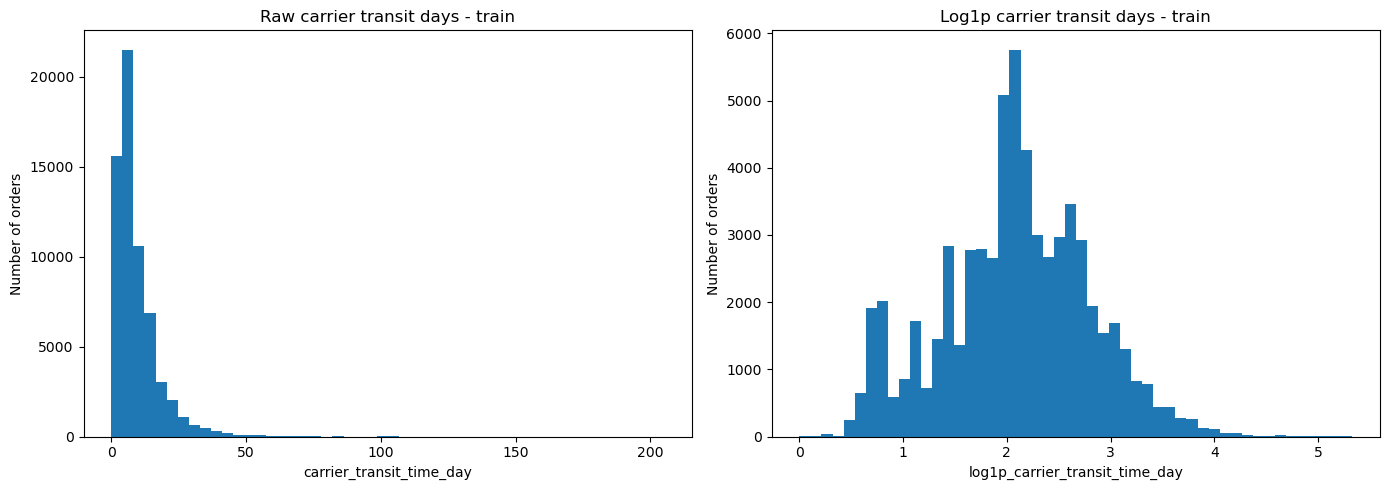

In [47]:
# Visualize raw vs log1p target distribution on train set only

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_train["carrier_transit_time_day"], bins=50)
axes[0].set_title("Raw carrier transit days - train")
axes[0].set_xlabel("carrier_transit_time_day")
axes[0].set_ylabel("Number of orders")

axes[1].hist(df_train["log1p_carrier_transit_time_day"], bins=50)
axes[1].set_title("Log1p carrier transit days - train")
axes[1].set_xlabel("log1p_carrier_transit_time_day")
axes[1].set_ylabel("Number of orders")

plt.tight_layout()
plt.show()

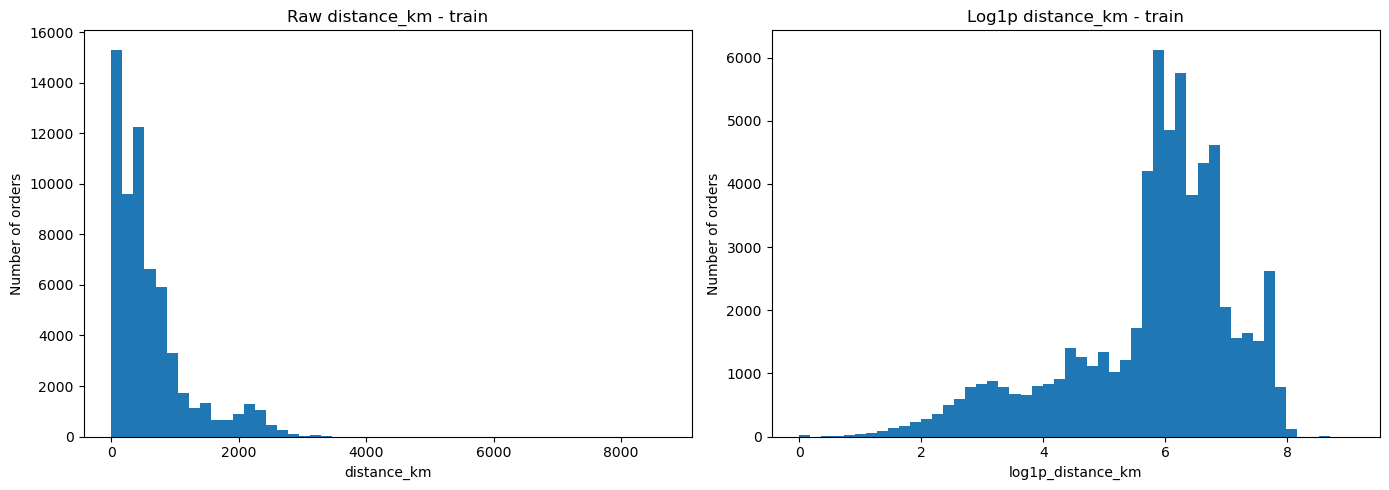

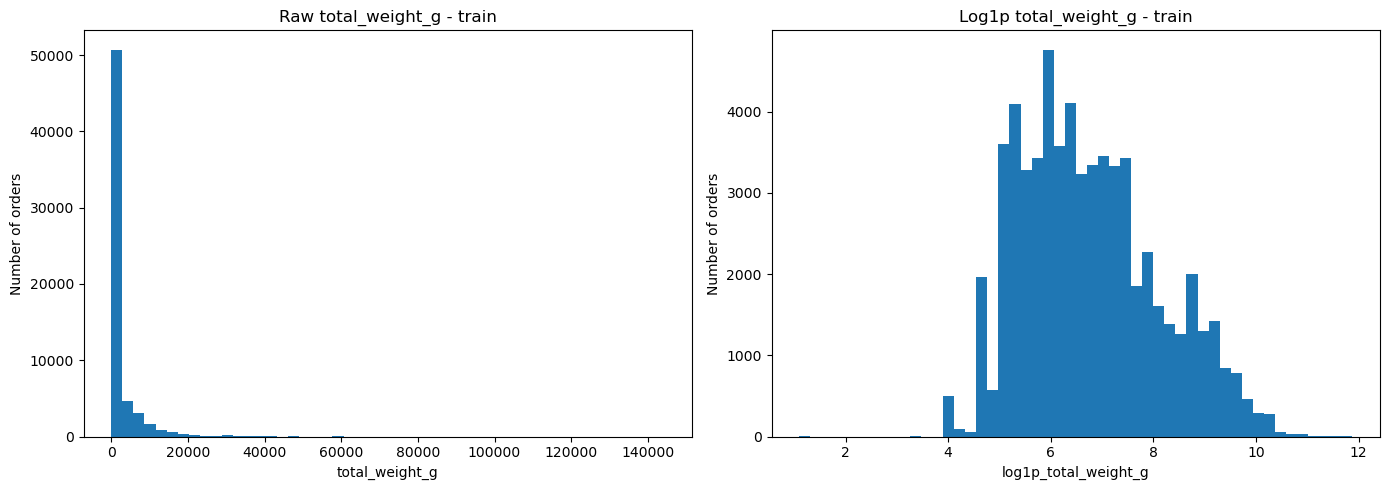

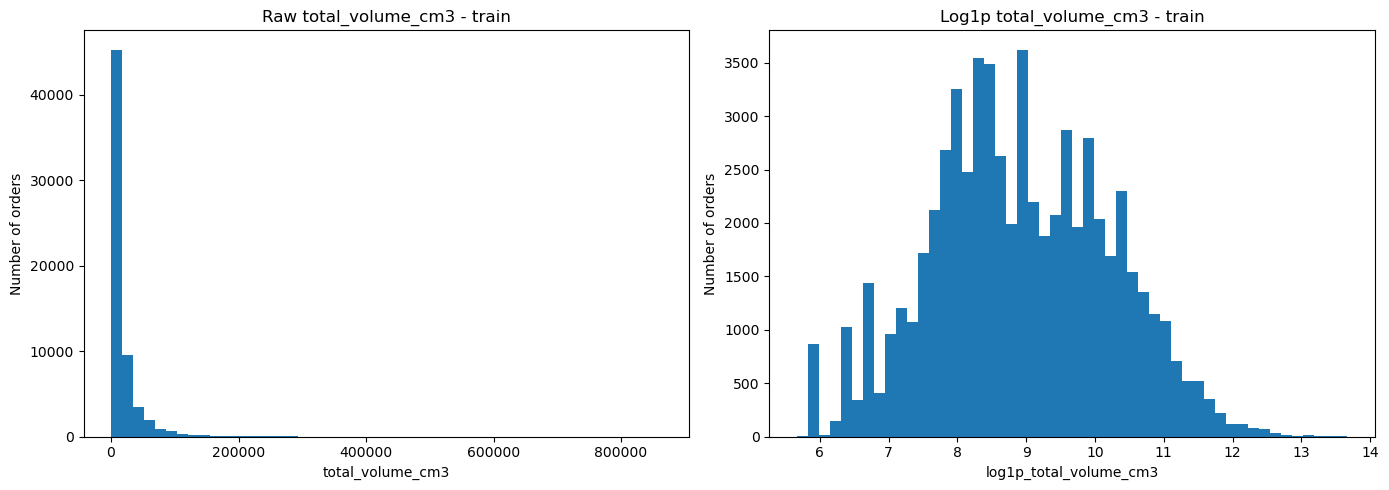

In [48]:
# Visualize raw vs log1p feature distributions on train set only

feature_pairs = [
    ("distance_km", "log1p_distance_km"),
    ("total_weight_g", "log1p_total_weight_g"),
    ("total_volume_cm3", "log1p_total_volume_cm3")
]

for raw_col, log_col in feature_pairs:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(df_train[raw_col], bins=50)
    axes[0].set_title(f"Raw {raw_col} - train")
    axes[0].set_xlabel(raw_col)
    axes[0].set_ylabel("Number of orders")
    
    axes[1].hist(df_train[log_col], bins=50)
    axes[1].set_title(f"Log1p {raw_col} - train")
    axes[1].set_xlabel(log_col)
    axes[1].set_ylabel("Number of orders")
    
    plt.tight_layout()
    plt.show()

In [49]:
# Confirm model-ready transformed columns are available in all splits

required_transformed_cols = [
    "log1p_carrier_transit_time_day",
    "log1p_distance_km",
    "log1p_total_weight_g",
    "log1p_total_volume_cm3",
    "seller_state_model",
    "order_month_model",
    "order_dayofweek_model"
]

for dataset_name, df_part in [
    ("train", df_train),
    ("validation", df_valid),
    ("test", df_test)
]:
    missing_cols = [col for col in required_transformed_cols if col not in df_part.columns]
    
    print(f"{dataset_name}:")
    print("Missing columns:", missing_cols if missing_cols else "None")
    print("Shape:", df_part.shape)
    print()

train:
Missing columns: None
Shape: (62717, 18)

validation:
Missing columns: None
Shape: (13439, 18)

test:
Missing columns: None
Shape: (13440, 18)



### Outliers and Skewed Variable Transformation

In this step, the continuous variables were reviewed for skewness and extreme values using the training set as the main reference.

The variables `distance_km`, `total_weight_g`, `total_volume_cm3`, and `carrier_transit_time_day` show right-skewed distributions. Therefore, `log1p` transformations were created to reduce skewness and make the variables more suitable for linear regression modeling.

The `log1p` transformation was applied consistently to the train, validation, and test sets because it is a fixed mathematical transformation and does not learn any parameter from the data.

However, any rule that depends on the data distribution, such as outlier capping thresholds, imputation values, rare category grouping, or scaling parameters, must be learned from the training set only and then applied to the validation and test sets.

At this stage, outliers are only flagged for diagnostic purposes. They are not removed or capped because extreme transit times, long distances, heavy packages, or large-volume orders may still represent valid operational cases that the benchmark model should learn from.

Both raw target and log-transformed target are kept as candidate modeling approaches:

- Raw target model: uses `carrier_transit_time_day` directly.
- Log target model: uses `log1p_carrier_transit_time_day`.

The final choice between raw target and log1p target is not made in this step. It will be decided later after fitting candidate models and comparing their validation/test performance using predictive metrics such as MAE, RMSE, mean residual, median residual, and calibration.

For the next modeling steps, the main transformed candidate features are:

- `log1p_distance_km`
- `log1p_total_weight_g`
- `log1p_total_volume_cm3`

The target candidates are:

- `carrier_transit_time_day`
- `log1p_carrier_transit_time_day`

### 4.4. Encoding Categorical Variables

In [52]:
# Encode categorical variables with SP as seller_state reference category

categorical_features = [
    "order_month_model",
    "order_dayofweek_model",
    "seller_state_model"
]

numeric_features = [
    "log1p_distance_km",
    "log1p_total_weight_g",
    "log1p_total_volume_cm3"
]

seller_state_categories_train = list(df_train["seller_state_model"].cat.categories)

if "SP" in seller_state_categories_train:
    seller_state_categories_ordered = (
        ["SP"]
        + [cat for cat in seller_state_categories_train if cat != "SP"]
    )
else:
    seller_state_categories_ordered = seller_state_categories_train

month_categories_ordered = list(range(1, 13))
weekday_categories_ordered = list(range(0, 7))

encoder_categories = [
    month_categories_ordered,
    weekday_categories_ordered,
    seller_state_categories_ordered
]

try:
    ohe = OneHotEncoder(
        categories=encoder_categories,
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    ohe = OneHotEncoder(
        categories=encoder_categories,
        drop="first",
        handle_unknown="ignore",
        sparse=False
    )

X_train_cat = df_train[categorical_features]
X_valid_cat = df_valid[categorical_features]
X_test_cat = df_test[categorical_features]

ohe.fit(X_train_cat)

encoded_feature_names = ohe.get_feature_names_out(categorical_features)

X_train_cat_encoded = pd.DataFrame(
    ohe.transform(X_train_cat),
    columns=encoded_feature_names,
    index=df_train.index
)

X_valid_cat_encoded = pd.DataFrame(
    ohe.transform(X_valid_cat),
    columns=encoded_feature_names,
    index=df_valid.index
)

X_test_cat_encoded = pd.DataFrame(
    ohe.transform(X_test_cat),
    columns=encoded_feature_names,
    index=df_test.index
)

print("Dropped reference categories:")
print("order_month_model reference:", month_categories_ordered[0])
print("order_dayofweek_model reference:", weekday_categories_ordered[0])
print("seller_state_model reference:", seller_state_categories_ordered[0])

print("\nEncoded feature examples:")
print(encoded_feature_names[:30])

Dropped reference categories:
order_month_model reference: 1
order_dayofweek_model reference: 0
seller_state_model reference: SP

Encoded feature examples:
['order_month_model_2' 'order_month_model_3' 'order_month_model_4'
 'order_month_model_5' 'order_month_model_6' 'order_month_model_7'
 'order_month_model_8' 'order_month_model_9' 'order_month_model_10'
 'order_month_model_11' 'order_month_model_12' 'order_dayofweek_model_1'
 'order_dayofweek_model_2' 'order_dayofweek_model_3'
 'order_dayofweek_model_4' 'order_dayofweek_model_5'
 'order_dayofweek_model_6' 'seller_state_model_BA' 'seller_state_model_DF'
 'seller_state_model_MG' 'seller_state_model_PR' 'seller_state_model_RJ'
 'seller_state_model_RS' 'seller_state_model_SC'
 'seller_state_model_Other']


In [53]:
# Rebuild model matrices after re-encoding categorical variables

X_train_num = df_train[numeric_features].copy()
X_valid_num = df_valid[numeric_features].copy()
X_test_num = df_test[numeric_features].copy()

X_train_model = pd.concat([X_train_num, X_train_cat_encoded], axis=1)
X_valid_model = pd.concat([X_valid_num, X_valid_cat_encoded], axis=1)
X_test_model = pd.concat([X_test_num, X_test_cat_encoded], axis=1)

print("X_train_model shape:", X_train_model.shape)
print("X_valid_model shape:", X_valid_model.shape)
print("X_test_model shape:", X_test_model.shape)

print("\nDoes seller_state_model_SP still exist?")
print("seller_state_model_SP" in X_train_model.columns)

X_train_model shape: (62717, 28)
X_valid_model shape: (13439, 28)
X_test_model shape: (13440, 28)

Does seller_state_model_SP still exist?
False


In [54]:
# Prepare raw and log1p target candidates for later model fitting

y_train_raw = df_train["carrier_transit_time_day"].copy()
y_valid_raw = df_valid["carrier_transit_time_day"].copy()
y_test_raw = df_test["carrier_transit_time_day"].copy()

y_train_log = df_train["log1p_carrier_transit_time_day"].copy()
y_valid_log = df_valid["log1p_carrier_transit_time_day"].copy()
y_test_log = df_test["log1p_carrier_transit_time_day"].copy()

target_summary = pd.DataFrame({
    "dataset": ["train", "validation", "test"],
    "raw_target_mean": [
        y_train_raw.mean(),
        y_valid_raw.mean(),
        y_test_raw.mean()
    ],
    "raw_target_median": [
        y_train_raw.median(),
        y_valid_raw.median(),
        y_test_raw.median()
    ],
    "log_target_mean": [
        y_train_log.mean(),
        y_valid_log.mean(),
        y_test_log.mean()
    ],
    "log_target_median": [
        y_train_log.median(),
        y_valid_log.median(),
        y_test_log.median()
    ]
})

display(target_summary)

,dataset,raw_target_mean,raw_target_median,log_target_mean,log_target_median
0,train,9.362952,7.120833,2.082675,2.094433
1,validation,9.326335,7.103472,2.079586,2.092293
2,test,9.419819,7.112847,2.084205,2.093449


In [55]:
# Display final model feature list after categorical encoding

model_feature_list = pd.DataFrame({
    "feature_name": X_train_model.columns,
    "feature_type": [
        "numeric_log1p" if col in numeric_features else "one_hot_encoded_categorical"
        for col in X_train_model.columns
    ]
})

display(model_feature_list)

,feature_name,feature_type
0,log1p_distance_km,numeric_log1p
1,log1p_total_weight_g,numeric_log1p
2,log1p_total_volume_cm3,numeric_log1p
3,order_month_model_2,one_hot_encoded_categorical
4,order_month_model_3,one_hot_encoded_categorical
5,order_month_model_4,one_hot_encoded_categorical
6,order_month_model_5,one_hot_encoded_categorical
7,order_month_model_6,one_hot_encoded_categorical
8,order_month_model_7,one_hot_encoded_categorical
9,order_month_model_8,one_hot_encoded_categorical


### 4.5. Multicollinearity Check

In [57]:
# Check pairwise correlations among numeric transformed features on train set only
numeric_corr_train = X_train_model[numeric_features].corr()

display(numeric_corr_train)

,log1p_distance_km,log1p_total_weight_g,log1p_total_volume_cm3
log1p_distance_km,1.000000,0.041640,0.025688
log1p_total_weight_g,0.041640,1.000000,0.776964
log1p_total_volume_cm3,0.025688,0.776964,1.000000


In [58]:
# Find high absolute correlations among all encoded model features on train set only

corr_matrix = X_train_model.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_corr_pairs.columns = ["feature_1", "feature_2", "abs_correlation"]

high_corr_pairs = (
    high_corr_pairs[high_corr_pairs["abs_correlation"] >= 0.80]
    .sort_values("abs_correlation", ascending=False)
    .reset_index(drop=True)
)

display(high_corr_pairs)

,feature_1,feature_2,abs_correlation


In [59]:
# Create vif_result from the encoded train feature matrix for multicollinearity checking

X_vif = X_train_model.copy()

constant_cols = [
    col for col in X_vif.columns
    if X_vif[col].nunique(dropna=False) <= 1
]

if constant_cols:
    X_vif = X_vif.drop(columns=constant_cols)

X_vif_const = add_constant(X_vif, has_constant="add")

vif_result = pd.DataFrame({
    "feature": X_vif_const.columns,
    "vif": [
        variance_inflation_factor(X_vif_const.values, i)
        for i in range(X_vif_const.shape[1])
    ]
})

vif_result = (
    vif_result[vif_result["feature"] != "const"]
    .sort_values("vif", ascending=False)
    .reset_index(drop=True)
)

display(vif_result)

,feature,vif
0,log1p_total_weight_g,2.555805
1,log1p_total_volume_cm3,2.542351
2,order_month_model_8,2.119437
3,order_month_model_5,2.078034
4,order_month_model_3,2.019308
5,order_month_model_7,2.011693
6,order_month_model_6,1.990804
7,order_month_model_4,1.932452
8,order_month_model_2,1.902437
9,order_month_model_11,1.794900


VIF was checked mainly for continuous predictors. Very high VIF values for one-hot encoded seller_state variables are expected due to dummy-variable structure and imbalanced state distribution. Therefore, seller_state is kept as an origin-control variable, but individual seller_state coefficients will not be interpreted directly.

## Part V — MODEL BUILDING AND VALIDATION SELECTION

### 5.1. Fit Baseline OLS Model  

In [63]:
# Save checked model matrices after multicollinearity review for OLS fitting

X_train_model_checked = X_train_model.copy()
X_valid_model_checked = X_valid_model.copy()
X_test_model_checked = X_test_model.copy()

print("X_train_model_checked shape:", X_train_model_checked.shape)
print("X_valid_model_checked shape:", X_valid_model_checked.shape)
print("X_test_model_checked shape:", X_test_model_checked.shape)

print("Train/validation columns match:", X_train_model_checked.columns.equals(X_valid_model_checked.columns))
print("Train/test columns match:", X_train_model_checked.columns.equals(X_test_model_checked.columns))

X_train_model_checked shape: (62717, 28)
X_valid_model_checked shape: (13439, 28)
X_test_model_checked shape: (13440, 28)
Train/validation columns match: True
Train/test columns match: True


In [64]:
# Prepare OLS model matrices for train and validation only

X_train_ols = sm.add_constant(X_train_model_checked, has_constant="add")
X_valid_ols = sm.add_constant(X_valid_model_checked, has_constant="add")

X_valid_ols = X_valid_ols.reindex(columns=X_train_ols.columns, fill_value=0)

print("X_train_ols shape:", X_train_ols.shape)
print("X_valid_ols shape:", X_valid_ols.shape)
print("Train/validation columns match:", X_train_ols.columns.equals(X_valid_ols.columns))

X_train_ols shape: (62717, 29)
X_valid_ols shape: (13439, 29)
Train/validation columns match: True


In [65]:
# Fit two baseline OLS candidate models on train set only

ols_raw_y = sm.OLS(
    y_train_raw,
    X_train_ols
).fit()

ols_log_y = sm.OLS(
    y_train_log,
    X_train_ols
).fit()

ols_fit_summary = pd.DataFrame({
    "model": ["OLS Raw Target", "OLS Log1p Target"],
    "target": ["carrier_transit_time_day", "log1p_carrier_transit_time_day"],
    "n_train": [int(ols_raw_y.nobs), int(ols_log_y.nobs)],
    "r_squared_train": [ols_raw_y.rsquared, ols_log_y.rsquared],
    "adj_r_squared_train": [ols_raw_y.rsquared_adj, ols_log_y.rsquared_adj],
    "aic_train": [ols_raw_y.aic, ols_log_y.aic],
    "bic_train": [ols_raw_y.bic, ols_log_y.bic]
})

display(ols_fit_summary)

,model,target,n_train,r_squared_train,adj_r_squared_train,aic_train,bic_train
0,OLS Raw Target,carrier_transit_time_day,62717,0.245807,0.245470,431108.089042,431370.434289
1,OLS Log1p Target,log1p_carrier_transit_time_day,62717,0.461410,0.461169,97681.770204,97944.115450


### Conclusion: Fit Baseline OLS Model

In this step, two baseline OLS candidate models were fitted using the training set only.

The two candidate models are:

- Raw target OLS: uses `carrier_transit_time_day` directly.
- Log target OLS: uses `log1p_carrier_transit_time_day`.

Both models use the same prepared feature matrix from the previous steps.

The validation set is used only to generate candidate predictions and residuals for the next evaluation step. The test set is intentionally not used in this step because it must be kept untouched for the final model evaluation after model selection.

The prediction range table in this step is only a sanity check to ensure that model predictions are not obviously invalid. It is not used to select the final model.

The final choice between raw target OLS and log target OLS will be made in the next step using validation metrics such as:

- MAE
- RMSE
- mean residual
- median residual
- residual bias
- calibration

Coefficient significance, p-values, and training R² are not used as the main model selection criteria because the purpose of this project is predictive benchmarking, not explanatory inference.

### 5.2. Evaluate Baseline OLS Models on Validation Set

In [68]:
# Build validation predictions for all candidate models before evaluating validation performance

if "y_train_raw" not in globals():
    y_train_raw = df_train["carrier_transit_time_day"].copy()

if "y_train_log" not in globals():
    y_train_log = df_train["log1p_carrier_transit_time_day"].copy()

if "X_train_ols" not in globals():
    X_train_ols = sm.add_constant(X_train_model_checked, has_constant="add")

if "X_valid_ols" not in globals():
    X_valid_ols = sm.add_constant(X_valid_model_checked, has_constant="add")
    X_valid_ols = X_valid_ols.reindex(columns=X_train_ols.columns, fill_value=0)

if "ols_raw_y" not in globals():
    ols_raw_y = sm.OLS(y_train_raw, X_train_ols).fit()

if "ols_log_y" not in globals():
    ols_log_y = sm.OLS(y_train_log, X_train_ols).fit()

y_valid_actual = df_valid["carrier_transit_time_day"].copy()

train_median_target = y_train_raw.median()

pred_valid_naive = pd.Series(
    np.repeat(train_median_target, len(df_valid)),
    index=df_valid.index,
    name="expected_days_naive_median"
)

pred_valid_raw_ols = pd.Series(
    np.clip(ols_raw_y.predict(X_valid_ols), a_min=0, a_max=None),
    index=df_valid.index,
    name="expected_days_raw_ols"
)

pred_valid_log_ols_no_smearing = pd.Series(
    np.clip(np.expm1(ols_log_y.predict(X_valid_ols)), a_min=0, a_max=None),
    index=df_valid.index,
    name="expected_days_log_ols_no_smearing"
)

log_smearing_factor = np.exp(ols_log_y.resid).mean()

pred_valid_log_ols_smearing = pd.Series(
    np.clip(
        np.exp(ols_log_y.predict(X_valid_ols)) * log_smearing_factor - 1,
        a_min=0,
        a_max=None
    ),
    index=df_valid.index,
    name="expected_days_log_ols_smearing"
)

valid_eval_scored = df_valid.copy()

valid_eval_scored["expected_days_naive_median"] = pred_valid_naive
valid_eval_scored["expected_days_raw_ols"] = pred_valid_raw_ols
valid_eval_scored["expected_days_log_ols_no_smearing"] = pred_valid_log_ols_no_smearing
valid_eval_scored["expected_days_log_ols_smearing"] = pred_valid_log_ols_smearing

valid_eval_scored["residual_naive_median"] = (
    valid_eval_scored["carrier_transit_time_day"]
    - valid_eval_scored["expected_days_naive_median"]
)

valid_eval_scored["residual_raw_ols"] = (
    valid_eval_scored["carrier_transit_time_day"]
    - valid_eval_scored["expected_days_raw_ols"]
)

valid_eval_scored["residual_log_ols_no_smearing"] = (
    valid_eval_scored["carrier_transit_time_day"]
    - valid_eval_scored["expected_days_log_ols_no_smearing"]
)

valid_eval_scored["residual_log_ols_smearing"] = (
    valid_eval_scored["carrier_transit_time_day"]
    - valid_eval_scored["expected_days_log_ols_smearing"]
)

display(valid_eval_scored[
    [
        "carrier_transit_time_day",
        "expected_days_naive_median",
        "expected_days_raw_ols",
        "expected_days_log_ols_no_smearing",
        "expected_days_log_ols_smearing",
        "residual_naive_median",
        "residual_raw_ols",
        "residual_log_ols_no_smearing",
        "residual_log_ols_smearing"
    ]
].head())

,carrier_transit_time_day,expected_days_naive_median,expected_days_raw_ols,expected_days_log_ols_no_smearing,expected_days_log_ols_smearing,residual_naive_median,residual_raw_ols,residual_log_ols_no_smearing,residual_log_ols_smearing
94110,6.163194,7.120833,5.862412,4.992269,5.983397,-0.957639,0.300783,1.170926,0.179797
35445,22.887500,7.120833,12.918401,10.627936,12.551211,15.766667,9.969099,12.259564,10.336289
89899,1.021528,7.120833,0.000000,0.481018,0.725980,-6.099306,1.021528,0.540510,0.295548
38541,9.918750,7.120833,11.724972,8.577333,10.161436,2.797917,-1.806222,1.341417,-0.242686
24480,15.348611,7.120833,8.664410,6.726452,8.004416,8.227778,6.684201,8.622159,7.344195


In [69]:
# Compare validation metrics for all candidate benchmark models safely

if "X_train_ols" not in globals():
    X_train_ols = sm.add_constant(X_train_model_checked, has_constant="add")

if "X_valid_ols" not in globals():
    X_valid_ols = sm.add_constant(X_valid_model_checked, has_constant="add")
    X_valid_ols = X_valid_ols.reindex(columns=X_train_ols.columns, fill_value=0)

if "y_train_raw" not in globals():
    y_train_raw = df_train["carrier_transit_time_day"].copy()

if "y_train_log" not in globals():
    y_train_log = np.log1p(df_train["carrier_transit_time_day"])

if "ols_raw_y" not in globals():
    ols_raw_y = sm.OLS(y_train_raw, X_train_ols).fit()

if "ols_log_y" not in globals():
    ols_log_y = sm.OLS(y_train_log, X_train_ols).fit()

y_valid_actual = df_valid["carrier_transit_time_day"].copy()

train_median_target = y_train_raw.median()
log_smearing_factor = np.exp(ols_log_y.resid).mean()

valid_eval_scored = df_valid.copy()

valid_eval_scored["expected_days_naive_median"] = np.repeat(
    train_median_target,
    len(df_valid)
)

valid_eval_scored["expected_days_raw_ols"] = np.clip(
    ols_raw_y.predict(X_valid_ols),
    a_min=0,
    a_max=None
)

valid_eval_scored["expected_days_log_ols_no_smearing"] = np.clip(
    np.expm1(ols_log_y.predict(X_valid_ols)),
    a_min=0,
    a_max=None
)

valid_eval_scored["expected_days_log_ols_smearing"] = np.clip(
    np.exp(ols_log_y.predict(X_valid_ols)) * log_smearing_factor - 1,
    a_min=0,
    a_max=None
)

def evaluate_validation_model(y_true, y_pred, model_name):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float)
    
    residual = y_true - y_pred
    abs_residual = residual.abs()
    
    return {
        "model": model_name,
        "n_validation_orders": len(y_true),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "median_absolute_error": median_absolute_error(y_true, y_pred),
        "mean_residual": residual.mean(),
        "median_residual": residual.median(),
        "abs_mean_residual": abs(residual.mean()),
        "abs_median_residual": abs(residual.median()),
        "pct_residual_positive": (residual > 0).mean(),
        "p90_abs_residual": np.percentile(abs_residual, 90),
        "p95_abs_residual": np.percentile(abs_residual, 95)
    }

validation_model_comparison = pd.DataFrame([
    evaluate_validation_model(
        y_valid_actual,
        valid_eval_scored["expected_days_naive_median"],
        "Naive Train Median"
    ),
    evaluate_validation_model(
        y_valid_actual,
        valid_eval_scored["expected_days_raw_ols"],
        "OLS Raw Target"
    ),
    evaluate_validation_model(
        y_valid_actual,
        valid_eval_scored["expected_days_log_ols_no_smearing"],
        "OLS Log1p Target"
    ),
    evaluate_validation_model(
        y_valid_actual,
        valid_eval_scored["expected_days_log_ols_smearing"],
        "OLS Log1p Target + Smearing"
    )
])

naive_mae = validation_model_comparison.loc[
    validation_model_comparison["model"] == "Naive Train Median",
    "mae"
].iloc[0]

naive_rmse = validation_model_comparison.loc[
    validation_model_comparison["model"] == "Naive Train Median",
    "rmse"
].iloc[0]

validation_model_comparison["mae_improvement_vs_naive"] = (
    naive_mae - validation_model_comparison["mae"]
)

validation_model_comparison["rmse_improvement_vs_naive"] = (
    naive_rmse - validation_model_comparison["rmse"]
)

validation_model_comparison = validation_model_comparison.sort_values(
    ["mae", "abs_median_residual", "abs_mean_residual"],
    ascending=[True, True, True]
).reset_index(drop=True)

display(validation_model_comparison)

,model,n_validation_orders,mae,rmse,median_absolute_error,mean_residual,median_residual,abs_mean_residual,abs_median_residual,pct_residual_positive,p90_abs_residual,p95_abs_residual,mae_improvement_vs_naive,rmse_improvement_vs_naive
0,OLS Log1p Target,13439,4.093684,7.469899,2.467915,1.454490,-0.204758,1.454490,0.204758,0.477416,8.786223,13.626354,1.218644,1.402228
1,OLS Log1p Target + Smearing,13439,4.326805,7.279903,3.036343,-0.012922,-1.395456,0.012922,1.395456,0.353598,8.510767,12.347354,0.985522,1.592224
2,OLS Raw Target,13439,4.535153,7.407163,3.345909,-0.062950,-1.491646,0.062950,1.491646,0.375995,8.535660,12.138937,0.777175,1.464964
3,Naive Train Median,13439,5.312328,8.872128,3.808333,2.205501,-0.017361,2.205501,0.017361,0.496912,11.926250,17.332083,0.000000,0.000000


### 5.3. Model Selection Decision

Based on the validation results, the preliminary champion model is:

**OLS Log1p Target without Smearing**

This model is selected because it best matches the objective of this project: building a model-adjusted benchmark for transit days and using residuals for state/city-level dashboard analysis.

Compared with the other candidate models, `OLS Log1p Target` has:

- the lowest MAE;
- the lowest median absolute error;
- a median residual closest to zero among the regression models;
- a residual-positive rate close to 50%;
- better alignment with a median-residual dashboard.

`OLS Log1p Target + Smearing` has a better RMSE and mean residual, but its median residual is strongly negative. This means the smearing-adjusted model tends to produce expected transit days that are too high for the median order, which can bias the dashboard toward showing many orders or states as faster than expected.

`OLS Raw Target` is not selected because it has higher MAE and a more negative median residual than the log-target model.

`Naive Train Median` is not selected even though its median residual is close to zero, because it does not adjust for order-level characteristics such as distance, weight, volume, order timing, and seller state.

Therefore, the selected validation-stage champion is:

**OLS Log1p Target without Smearing**

This is still a preliminary champion selected on the validation set only. The untouched test set will be used later for final confirmation.

In [75]:
# Set validation-stage champion model and create champion prediction/residual columns safely

preliminary_champion_model = "OLS Log1p Target"

champion_expected_col_valid = "expected_days_log_ols_no_smearing"
champion_residual_col_valid = "residual_log_ols_no_smearing"

if champion_expected_col_valid not in valid_eval_scored.columns:
    raise KeyError(f"Missing champion expected column: {champion_expected_col_valid}")

if champion_residual_col_valid not in valid_eval_scored.columns:
    valid_eval_scored[champion_residual_col_valid] = (
        valid_eval_scored["carrier_transit_time_day"]
        - valid_eval_scored[champion_expected_col_valid]
    )

valid_eval_scored["expected_days_champion"] = valid_eval_scored[champion_expected_col_valid]
valid_eval_scored["residual_champion"] = valid_eval_scored[champion_residual_col_valid]

print("Preliminary champion model:", preliminary_champion_model)
print("Champion expected column:", champion_expected_col_valid)
print("Champion residual column:", champion_residual_col_valid)

display(valid_eval_scored[
    [
        "carrier_transit_time_day",
        "expected_days_champion",
        "residual_champion"
    ]
].head())

Preliminary champion model: OLS Log1p Target
Champion expected column: expected_days_log_ols_no_smearing
Champion residual column: residual_log_ols_no_smearing


,carrier_transit_time_day,expected_days_champion,residual_champion
94110,6.163194,4.992269,1.170926
35445,22.887500,10.627936,12.259564
89899,1.021528,0.481018,0.540510
38541,9.918750,8.577333,1.341417
24480,15.348611,6.726452,8.622159


In [77]:
# Set validation-stage champion model and create champion prediction/residual columns

preliminary_champion_model = "OLS Log1p Target"

champion_expected_col_valid = "expected_days_log_ols_no_smearing"
champion_residual_col_valid = "residual_log_ols_no_smearing"

valid_eval_scored["expected_days_champion"] = valid_eval_scored[champion_expected_col_valid]
valid_eval_scored["residual_champion"] = valid_eval_scored[champion_residual_col_valid]

print("Preliminary champion model:", preliminary_champion_model)
print("Champion expected column:", champion_expected_col_valid)
print("Champion residual column:", champion_residual_col_valid)

display(valid_eval_scored[
    [
        "carrier_transit_time_day",
        "expected_days_champion",
        "residual_champion"
    ]
].head())

Preliminary champion model: OLS Log1p Target
Champion expected column: expected_days_log_ols_no_smearing
Champion residual column: residual_log_ols_no_smearing


,carrier_transit_time_day,expected_days_champion,residual_champion
94110,6.163194,4.992269,1.170926
35445,22.887500,10.627936,12.259564
89899,1.021528,0.481018,0.540510
38541,9.918750,8.577333,1.341417
24480,15.348611,6.726452,8.622159


## Part VI — CHAMPION MODEL DIAGNOSTICS


### 6.1. Residual Bias / Model Specification Check

In [81]:
# Run compact diagnostics on the selected champion model only

diagnostic_df = valid_eval_scored.copy()

diagnostic_df["actual_transit_days"] = diagnostic_df["carrier_transit_time_day"]
diagnostic_df["expected_transit_days"] = diagnostic_df["expected_days_log_ols_no_smearing"]
diagnostic_df["residual_days"] = diagnostic_df["residual_log_ols_no_smearing"]
diagnostic_df["abs_residual_days"] = diagnostic_df["residual_days"].abs()

diagnostic_summary = pd.DataFrame({
    "metric": [
        "n_validation_orders",
        "mean_residual",
        "median_residual",
        "mae",
        "pct_residual_positive"
    ],
    "value": [
        len(diagnostic_df),
        diagnostic_df["residual_days"].mean(),
        diagnostic_df["residual_days"].median(),
        diagnostic_df["abs_residual_days"].mean(),
        (diagnostic_df["residual_days"] > 0).mean()
    ]
})

display(diagnostic_summary)

,metric,value
0,n_validation_orders,13439.000000
1,mean_residual,1.454490
2,median_residual,-0.204758
3,mae,4.093684
4,pct_residual_positive,0.477416


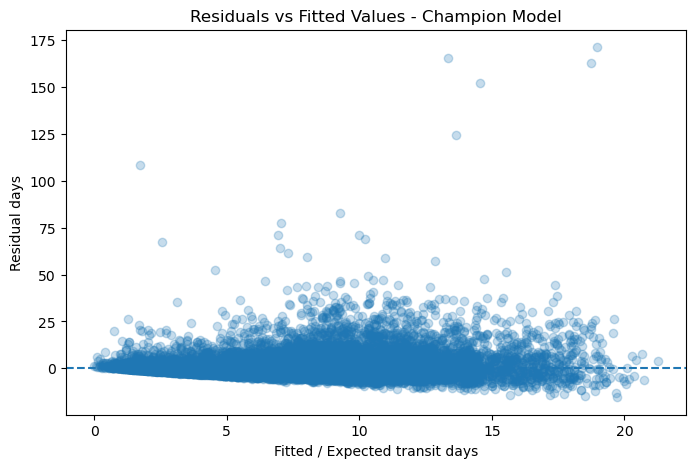

In [83]:
# Plot residuals vs fitted values to check bias, specification pattern, and heteroscedasticity

plt.figure(figsize=(8, 5))
plt.scatter(
    diagnostic_df["expected_transit_days"],
    diagnostic_df["residual_days"],
    alpha=0.25
)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted / Expected transit days")
plt.ylabel("Residual days")
plt.title("Residuals vs Fitted Values - Champion Model")
plt.show()

The residuals vs fitted plot does not show a strong nonlinear pattern. Most residuals are randomly scattered around zero, suggesting that the baseline log-target OLS model captures the main structure reasonably well.

However, the residual spread becomes somewhat wider as expected transit days increase, and there are several large positive residuals. This suggests mild-to-moderate heteroscedasticity and a positive long-tail error pattern, especially for difficult orders with higher expected transit days.

This does not invalidate the model for predictive benchmarking, especially because the project focuses on median residuals rather than coefficient inference. However, it should be reported as a limitation: the benchmark is less precise for high-expected-transit orders and extreme late deliveries.

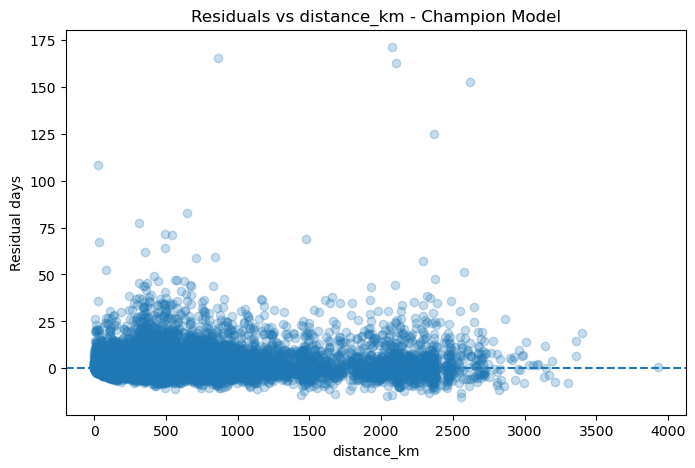

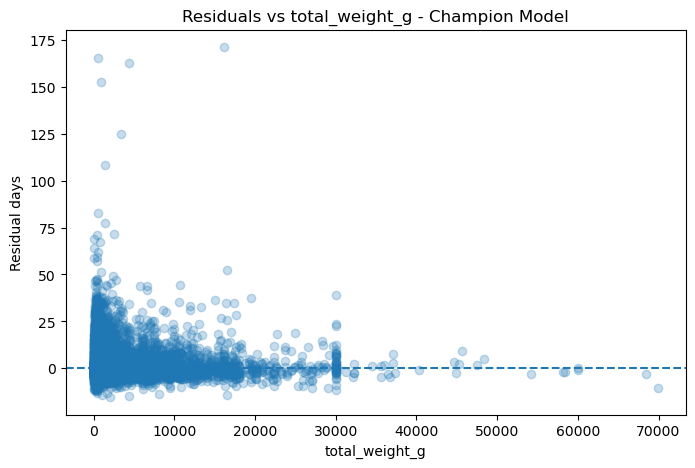

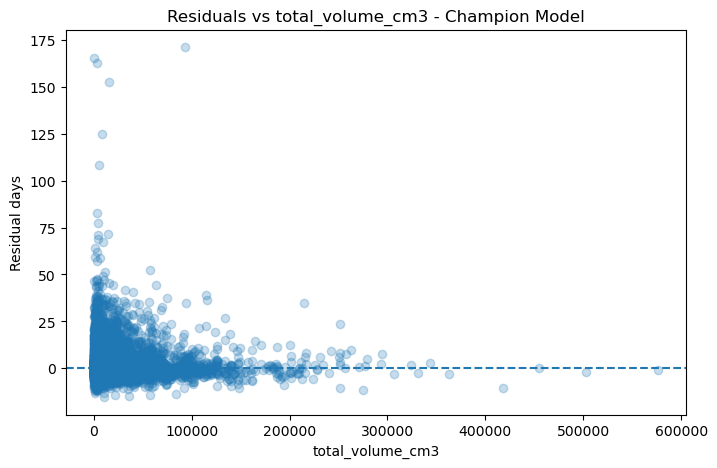

In [86]:
# Plot residuals vs key continuous predictors to check nonlinearity and systematic bias

x_vars_to_check = [
    "distance_km",
    "total_weight_g",
    "total_volume_cm3"
]

x_vars_to_check = [
    col for col in x_vars_to_check
    if col in diagnostic_df.columns
]

for col in x_vars_to_check:
    plt.figure(figsize=(8, 5))
    plt.scatter(
        diagnostic_df[col],
        diagnostic_df["residual_days"],
        alpha=0.25
    )
    plt.axhline(0, linestyle="--")
    plt.xlabel(col)
    plt.ylabel("Residual days")
    plt.title(f"Residuals vs {col} - Champion Model")
    plt.show()

Overall, the residual plots against distance, weight, and volume do not show severe functional-form problems. The residuals are generally scattered around zero, which suggests that the champion model captures the main relationships reasonably well.

The main concern is not a strong nonlinear pattern, but the presence of large positive residuals and wider residual spread for some difficult orders, especially long-distance orders. Weight and volume do not appear to be major sources of systematic residual bias.

Therefore, the model remains acceptable for a first-version model-adjusted benchmark, especially because the dashboard focuses on median residuals. However, the model should be reported as less precise for long-distance and extreme-delay orders.

### 6.2. Heteroscedasticity Check

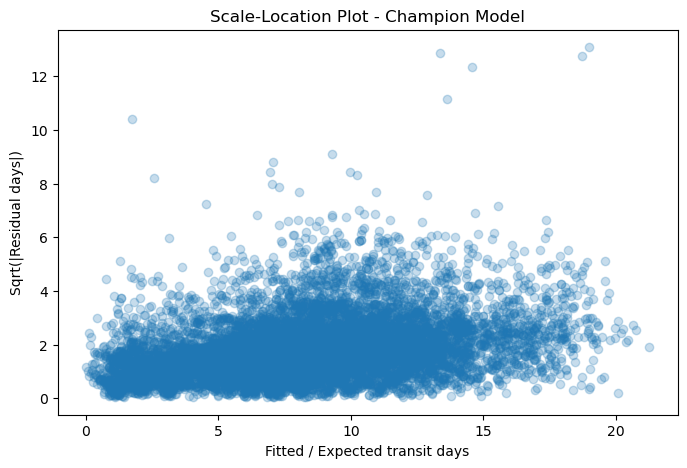

In [90]:
# Plot scale-location chart to check whether residual spread changes with fitted values

plt.figure(figsize=(8, 5))
plt.scatter(
    diagnostic_df["expected_transit_days"],
    np.sqrt(diagnostic_df["abs_residual_days"]),
    alpha=0.25
)
plt.xlabel("Fitted / Expected transit days")
plt.ylabel("Sqrt(|Residual days|)")
plt.title("Scale-Location Plot - Champion Model")
plt.show()

The scale-location plot shows that residual spread is not perfectly constant across fitted values. The spread of `sqrt(|residual|)` increases from low expected transit days to mid/high expected transit days, suggesting mild-to-moderate heteroscedasticity.

This means the champion model is less precise for orders with higher expected transit days. However, the pattern is not severe enough to reject the model for the current benchmarking purpose.

Since this project focuses on predictive benchmarking and median residuals rather than coefficient inference, this heteroscedasticity is mainly a model limitation rather than a critical failure. The benchmark should be interpreted more carefully for difficult orders with high expected transit days and large positive residuals.

Overall, the residual diagnostics do not show a severe functional-form problem. Residuals are generally scattered around zero, but there is mild-to-moderate heteroscedasticity and a positive long-tail caused by extreme late deliveries. The model remains usable for median-residual benchmarking, but it is less precise for difficult or high-expected-transit orders.

## Part VII — FINAL HOLDOUT TEST EVALUATION


In [95]:
# Prepare test model matrix for final champion evaluation

if "X_test_model_checked" not in globals():
    X_test_model_checked = X_test_model.copy()

X_test_ols = sm.add_constant(X_test_model_checked, has_constant="add")
X_test_ols = X_test_ols.reindex(columns=X_train_ols.columns, fill_value=0)

print("X_test_ols shape:", X_test_ols.shape)
print("Train/test columns match:", X_train_ols.columns.equals(X_test_ols.columns))

X_test_ols shape: (13440, 29)
Train/test columns match: True


In [97]:
# Generate test predictions using selected champion model only

y_test_actual = df_test["carrier_transit_time_day"].copy()

pred_test_champion = np.clip(
    np.expm1(ols_log_y.predict(X_test_ols)),
    a_min=0,
    a_max=None
)

test_eval_scored = df_test.copy()

test_eval_scored["actual_transit_days"] = y_test_actual
test_eval_scored["expected_transit_days_champion"] = pred_test_champion
test_eval_scored["residual_days_champion"] = (
    test_eval_scored["actual_transit_days"]
    - test_eval_scored["expected_transit_days_champion"]
)
test_eval_scored["abs_residual_days_champion"] = (
    test_eval_scored["residual_days_champion"].abs()
)
test_eval_scored["is_slower_than_expected_champion"] = (
    test_eval_scored["residual_days_champion"] > 0
)

display(test_eval_scored[
    [
        "actual_transit_days",
        "expected_transit_days_champion",
        "residual_days_champion",
        "abs_residual_days_champion",
        "is_slower_than_expected_champion"
    ]
].head())

,actual_transit_days,expected_transit_days_champion,residual_days_champion,abs_residual_days_champion,is_slower_than_expected_champion
84160,6.070139,7.786136,-1.715997,1.715997,False
18932,8.167361,6.615433,1.551928,1.551928,True
78977,8.077778,12.533657,-4.455879,4.455879,False
26165,14.148611,13.067525,1.081086,1.081086,True
74099,6.345139,7.917128,-1.571989,1.571989,False


### Final Test Evaluation On Champion Model

In [100]:
# Evaluate champion model on untouched test set

def evaluate_model_on_dataset(y_true, y_pred, dataset_name, model_name):
    residual = y_true - y_pred
    abs_residual = np.abs(residual)
    
    return {
        "dataset": dataset_name,
        "model": model_name,
        "n_orders": len(y_true),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "median_absolute_error": median_absolute_error(y_true, y_pred),
        "mean_residual": residual.mean(),
        "median_residual": residual.median(),
        "abs_mean_residual": abs(residual.mean()),
        "abs_median_residual": abs(residual.median()),
        "pct_residual_positive": (residual > 0).mean(),
        "p90_abs_residual": np.percentile(abs_residual, 90),
        "p95_abs_residual": np.percentile(abs_residual, 95)
    }

test_champion_metrics = pd.DataFrame([
    evaluate_model_on_dataset(
        y_test_actual,
        test_eval_scored["expected_transit_days_champion"],
        "test",
        "OLS Log1p Target"
    )
])

display(test_champion_metrics)

,dataset,model,n_orders,mae,rmse,median_absolute_error,mean_residual,median_residual,abs_mean_residual,abs_median_residual,pct_residual_positive,p90_abs_residual,p95_abs_residual
0,test,OLS Log1p Target,13440,4.172921,7.892587,2.447755,1.515606,-0.225315,1.515606,0.225315,0.47314,8.892223,13.858665


In [102]:
# Compare validation and test performance for the selected champion model

validation_champion_metrics = pd.DataFrame([
    evaluate_model_on_dataset(
        valid_eval_scored["carrier_transit_time_day"],
        valid_eval_scored["expected_days_log_ols_no_smearing"],
        "validation",
        "OLS Log1p Target"
    )
])

champion_validation_test_comparison = pd.concat(
    [
        validation_champion_metrics,
        test_champion_metrics
    ],
    ignore_index=True
)

display(champion_validation_test_comparison)

,dataset,model,n_orders,mae,rmse,median_absolute_error,mean_residual,median_residual,abs_mean_residual,abs_median_residual,pct_residual_positive,p90_abs_residual,p95_abs_residual
0,validation,OLS Log1p Target,13439,4.093684,7.469899,2.467915,1.454490,-0.204758,1.454490,0.204758,0.477416,8.786223,13.626354
1,test,OLS Log1p Target,13440,4.172921,7.892587,2.447755,1.515606,-0.225315,1.515606,0.225315,0.473140,8.892223,13.858665


In [104]:
# Compare champion model against naive train-median baseline on test set

train_median_target = y_train_raw.median()

pred_test_naive = pd.Series(
    np.repeat(train_median_target, len(df_test)),
    index=df_test.index,
    name="expected_days_naive_median"
)

test_naive_metrics = pd.DataFrame([
    evaluate_model_on_dataset(
        y_test_actual,
        pred_test_naive,
        "test",
        "Naive Train Median"
    )
])

test_final_comparison = pd.concat(
    [
        test_champion_metrics,
        test_naive_metrics
    ],
    ignore_index=True
)

naive_test_mae = test_final_comparison.loc[
    test_final_comparison["model"] == "Naive Train Median",
    "mae"
].iloc[0]

naive_test_rmse = test_final_comparison.loc[
    test_final_comparison["model"] == "Naive Train Median",
    "rmse"
].iloc[0]

test_final_comparison["mae_improvement_vs_naive"] = (
    naive_test_mae - test_final_comparison["mae"]
)

test_final_comparison["rmse_improvement_vs_naive"] = (
    naive_test_rmse - test_final_comparison["rmse"]
)

display(test_final_comparison)

,dataset,model,n_orders,mae,rmse,median_absolute_error,mean_residual,median_residual,abs_mean_residual,abs_median_residual,pct_residual_positive,p90_abs_residual,p95_abs_residual,mae_improvement_vs_naive,rmse_improvement_vs_naive
0,test,OLS Log1p Target,13440,4.172921,7.892587,2.447755,1.515606,-0.225315,1.515606,0.225315,0.473140,8.892223,13.858665,1.198998,1.332563
1,test,Naive Train Median,13440,5.371919,9.225150,3.730903,2.298986,-0.007986,2.298986,0.007986,0.497842,11.912569,17.652257,0.000000,0.000000


In [105]:
# Make final pass/fail check for champion model on test set

test_mae_improvement_vs_naive = test_final_comparison.loc[
    test_final_comparison["model"] == "OLS Log1p Target",
    "mae_improvement_vs_naive"
].iloc[0]

final_test_checks = pd.DataFrame({
    "check": [
        "Champion improves MAE versus naive baseline on test",
        "Absolute median residual on test <= 1 day",
        "Residual positive rate on test between 40% and 60%"
    ],
    "value": [
        test_mae_improvement_vs_naive,
        abs(test_eval_scored["residual_days_champion"].median()),
        test_eval_scored["is_slower_than_expected_champion"].mean()
    ],
    "passed": [
        test_mae_improvement_vs_naive > 0,
        abs(test_eval_scored["residual_days_champion"].median()) <= 1.0,
        0.40 <= test_eval_scored["is_slower_than_expected_champion"].mean() <= 0.60
    ]
})

display(final_test_checks)

if final_test_checks["passed"].all():
    print("Final test result: PASS. Champion model is confirmed for Power BI benchmark export.")
else:
    print("Final test result: REVIEW NEEDED before Power BI benchmark export.")

,check,value,passed
0,Champion improves MAE versus naive baseline on test,1.198998,True
1,Absolute median residual on test <= 1 day,0.225315,True
2,Residual positive rate on test between 40% and 60%,0.473140,True


Final test result: PASS. Champion model is confirmed for Power BI benchmark export.


### Part VIII — Business Reporting Output for Power BI

In [109]:
# Create Power BI state-level table using champion model and true late definition

state_name_map = {
    "AC": "Acre",
    "AL": "Alagoas",
    "AP": "Amapá",
    "AM": "Amazonas",
    "BA": "Bahia",
    "CE": "Ceará",
    "DF": "Distrito Federal",
    "ES": "Espírito Santo",
    "GO": "Goiás",
    "MA": "Maranhão",
    "MT": "Mato Grosso",
    "MS": "Mato Grosso do Sul",
    "MG": "Minas Gerais",
    "PA": "Pará",
    "PB": "Paraíba",
    "PR": "Paraná",
    "PE": "Pernambuco",
    "PI": "Piauí",
    "RJ": "Rio de Janeiro",
    "RN": "Rio Grande do Norte",
    "RS": "Rio Grande do Sul",
    "RO": "Rondônia",
    "RR": "Roraima",
    "SC": "Santa Catarina",
    "SP": "São Paulo",
    "SE": "Sergipe",
    "TO": "Tocantins"
}

state_col_candidates = [
    "customer_state",
    "cust_state",
    "customer_state_code",
    "cust_state_code",
    "customer_state_name",
    "state_name"
]

delivered_date_candidates = [
    "order_delivered_customer_date",
    "delivered_customer_date",
    "customer_delivery_date",
    "delivered_date"
]

estimated_date_candidates = [
    "order_estimated_delivery_date",
    "estimated_delivery_date",
    "estimated_customer_delivery_date"
]

state_col = next(
    (col for col in state_col_candidates if col in df_homo.columns),
    None
)

delivered_col = next(
    (col for col in delivered_date_candidates if col in df_homo.columns),
    None
)

estimated_col = next(
    (col for col in estimated_date_candidates if col in df_homo.columns),
    None
)

if state_col is None:
    raise KeyError(
        "Không tìm thấy cột customer state trong df_homo. "
        f"Các cột hiện có là: {df_homo.columns.tolist()}"
    )

if delivered_col is None or estimated_col is None:
    raise KeyError(
        "Không tìm thấy cột delivered date hoặc estimated delivery date trong df_homo. "
        f"Delivered candidates: {delivered_date_candidates}. "
        f"Estimated candidates: {estimated_date_candidates}. "
        f"Các cột hiện có là: {df_homo.columns.tolist()}"
    )

print("State column used:", state_col)
print("Delivered date column used:", delivered_col)
print("Estimated date column used:", estimated_col)

State column used: customer_state
Delivered date column used: order_delivered_customer_date
Estimated date column used: order_estimated_delivery_date


In [111]:
# Score all cleaned homogeneous orders using the selected champion model

powerbi_model_df = df_model_clean.copy()

def apply_seller_state_rare_rule_for_scoring(df, kept_states):
    df_out = df.copy()
    
    seller_state_clean = (
        df_out["seller_state"]
        .fillna("Unknown")
        .astype(str)
    )
    
    df_out["seller_state_model"] = np.where(
        seller_state_clean.isin(kept_states),
        seller_state_clean,
        "Other"
    )
    
    seller_state_categories = sorted(kept_states)
    if "Other" not in seller_state_categories:
        seller_state_categories.append("Other")
    
    df_out["seller_state_model"] = pd.Categorical(
        df_out["seller_state_model"],
        categories=seller_state_categories
    )
    
    return df_out

powerbi_model_df = apply_seller_state_rare_rule_for_scoring(
    powerbi_model_df,
    kept_seller_states
)

powerbi_model_df["order_month_model"] = pd.Categorical(
    powerbi_model_df["order_month"].astype("Int64"),
    categories=list(range(1, 13))
)

powerbi_model_df["order_dayofweek_model"] = pd.Categorical(
    powerbi_model_df["order_dayofweek"].astype("Int64"),
    categories=list(range(0, 7))
)

for col in [
    "carrier_transit_time_day",
    "distance_km",
    "total_weight_g",
    "total_volume_cm3"
]:
    if (powerbi_model_df[col] < 0).any():
        raise ValueError(f"{col} has negative values. log1p cannot be applied safely.")
    
    powerbi_model_df[f"log1p_{col}"] = np.log1p(powerbi_model_df[col])

X_powerbi_num = powerbi_model_df[numeric_features].copy()

X_powerbi_cat = powerbi_model_df[categorical_features].copy()

X_powerbi_cat_encoded = pd.DataFrame(
    ohe.transform(X_powerbi_cat),
    columns=encoded_feature_names,
    index=powerbi_model_df.index
)

X_powerbi_model = pd.concat(
    [X_powerbi_num, X_powerbi_cat_encoded],
    axis=1
)

X_powerbi_model = X_powerbi_model.reindex(
    columns=X_train_model_checked.columns,
    fill_value=0
)

X_powerbi_ols = sm.add_constant(
    X_powerbi_model,
    has_constant="add"
)

X_powerbi_ols = X_powerbi_ols.reindex(
    columns=X_train_ols.columns,
    fill_value=0
)

powerbi_model_df["expected_transit_days"] = np.clip(
    np.expm1(ols_log_y.predict(X_powerbi_ols)),
    a_min=0,
    a_max=None
)

powerbi_model_df["model_adjusted_residual_days"] = (
    powerbi_model_df["carrier_transit_time_day"]
    - powerbi_model_df["expected_transit_days"]
)

display(powerbi_model_df[
    [
        "carrier_transit_time_day",
        "expected_transit_days",
        "model_adjusted_residual_days"
    ]
].head())

,carrier_transit_time_day,expected_transit_days,model_adjusted_residual_days
0,1.608333,8.145321,-6.536987
1,3.000000,7.693971,-4.693971
2,6.073611,9.344269,-3.270658
3,8.959028,9.077723,-0.118696
4,9.863889,5.515126,4.348762


In [112]:
# Add customer state and true late flag from df_homo using the original row index

report_lookup = df_homo.loc[powerbi_model_df.index].copy()

powerbi_model_df["state_code_or_name"] = report_lookup[state_col].astype(str).str.strip()

powerbi_model_df["state_code_upper"] = (
    powerbi_model_df["state_code_or_name"]
    .str.upper()
)

powerbi_model_df["State Name"] = (
    powerbi_model_df["state_code_upper"]
    .map(state_name_map)
    .fillna(powerbi_model_df["state_code_or_name"])
)

actual_delivered_date = pd.to_datetime(
    report_lookup[delivered_col],
    errors="coerce"
)

estimated_delivery_date = pd.to_datetime(
    report_lookup[estimated_col],
    errors="coerce"
)

powerbi_model_df["late_flag"] = (
    actual_delivered_date > estimated_delivery_date
)

late_date_quality_check = pd.DataFrame({
    "check": [
        "Missing delivered date",
        "Missing estimated delivery date",
        "Late orders",
        "Late rate"
    ],
    "value": [
        int(actual_delivered_date.isna().sum()),
        int(estimated_delivery_date.isna().sum()),
        int(powerbi_model_df["late_flag"].sum()),
        powerbi_model_df["late_flag"].mean()
    ]
})

display(late_date_quality_check)

,check,value
0,Missing delivered date,0.000000
1,Missing estimated delivery date,0.000000
2,Late orders,7314.000000
3,Late rate,0.081633


In [113]:
# Aggregate to state-level table for Power BI using snake_case column names

powerbi_state_table = (
    powerbi_model_df
    .groupby("State Name", observed=True)
    .agg(
        total_orders=("carrier_transit_time_day", "count"),
        late_orders=("late_flag", "sum"),
        median_residual_day=("model_adjusted_residual_days", "median")
    )
    .reset_index()
    .rename(columns={
        "State Name": "state_name"
    })
)

powerbi_state_table["late_rate"] = (
    powerbi_state_table["late_orders"]
    / powerbi_state_table["total_orders"]
)

powerbi_state_table = powerbi_state_table[
    [
        "state_name",
        "total_orders",
        "late_orders",
        "late_rate",
        "median_residual_day"
    ]
].sort_values("state_name").reset_index(drop=True)

powerbi_state_table["total_orders"] = powerbi_state_table["total_orders"].astype(int)
powerbi_state_table["late_orders"] = powerbi_state_table["late_orders"].astype(int)
powerbi_state_table["late_rate"] = powerbi_state_table["late_rate"].round(4)
powerbi_state_table["median_residual_day"] = powerbi_state_table["median_residual_day"].round(1)

display(powerbi_state_table)

,state_name,total_orders,late_orders,late_rate,median_residual_day
0,Acre,73,3,0.0411,-0.5
1,Alagoas,376,88,0.2340,5.7
2,Amapá,63,2,0.0317,4.6
3,Amazonas,138,5,0.0362,7.6
4,Bahia,3018,415,0.1375,1.8
5,Ceará,1203,188,0.1563,1.3
6,Distrito Federal,1784,135,0.0757,-1.1
7,Espírito Santo,1851,219,0.1183,0.4
8,Goiás,1776,142,0.0800,1.2
9,Maranhão,663,130,0.1961,2.1


In [115]:
# Export snake_case Power BI CSV file to the selected OLIST Project folder

output_path = Path(
    r"C:\Users\PC\Downloads\SAT FILE\DATA ANALYST TOOLS\OLIST Project\powerbi_distance_adjusted_carrier_priority_by_state.csv"
)

output_path.parent.mkdir(parents=True, exist_ok=True)

powerbi_state_table.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print("Export completed:")
print(output_path)

print("File exists:", output_path.exists())
print("Rows exported:", len(powerbi_state_table))

Export completed:
C:\Users\PC\Downloads\SAT FILE\DATA ANALYST TOOLS\OLIST Project\powerbi_distance_adjusted_carrier_priority_by_state.csv
File exists: True
Rows exported: 27
